In [2]:
#pip install opencv-python

In [3]:
im1  = "nuts.png"
im2  = "coin1.jpg"
im3  = "shapes.png"
im4  = "geometric shapes.jpg"
im5  = "metals.jpg"
im6  = "items.png"
im7  = "geometric shapes_obj.jpeg"
im8  = "crops.jpg"
im9  = "ch.jpeg"
im10  = "boxes.jpg"
im11  = "fruits.jpg"

# Q1 – Nuts & Bolts Object Detection + Area Stats

Total detected objects: 146
Object 1: Area = 0.00 pixels
Object 2: Area = 0.00 pixels
Object 3: Area = 0.00 pixels
Object 4: Area = 0.00 pixels
Object 5: Area = 0.00 pixels
Object 6: Area = 0.00 pixels
Object 7: Area = 0.00 pixels
Object 8: Area = 0.00 pixels
Object 9: Area = 0.00 pixels
Object 10: Area = 0.00 pixels
Object 11: Area = 0.00 pixels
Object 12: Area = 0.00 pixels
Object 13: Area = 0.00 pixels
Object 14: Area = 0.00 pixels
Object 15: Area = 0.00 pixels
Object 16: Area = 0.00 pixels
Object 17: Area = 0.00 pixels
Object 18: Area = 0.50 pixels
Object 19: Area = 5427.00 pixels
Object 20: Area = 0.00 pixels
Object 21: Area = 0.00 pixels
Object 22: Area = 0.00 pixels
Object 23: Area = 0.00 pixels
Object 24: Area = 6.00 pixels
Object 25: Area = 0.00 pixels
Object 26: Area = 0.00 pixels
Object 27: Area = 0.00 pixels
Object 28: Area = 0.50 pixels
Object 29: Area = 0.50 pixels
Object 30: Area = 0.00 pixels
Object 31: Area = 0.00 pixels
Object 32: Area = 0.00 pixels
Object 33: Area = 

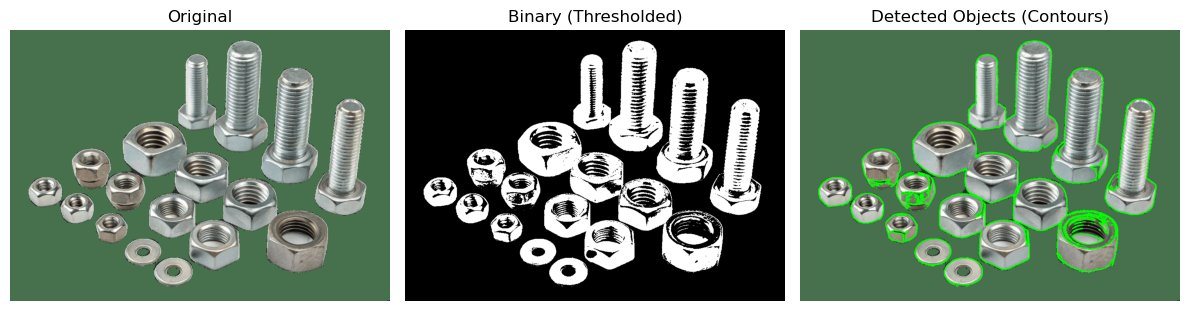

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Load image (similar to shapes.png example in notes)
img = cv2.imread(im1)
if img is None:
    raise FileNotFoundError("Could not find 'nuts_bolts.jpg' in the current folder.")

# Convert to grayscale (same idea as in object detection lab)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 2. Apply thresholding to segment objects from background
# If your objects are dark on light background, you may try THRESH_BINARY_INV instead.
_, binary = cv2.threshold(gray, 120, 255, cv2.THRESH_BINARY)

# 3. Find contours (object boundaries) - like in shapes.png example
contours, hierarchy = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

print(f"Total detected objects: {len(contours)}")

# 4. Compute area of each contour
areas = []
for i, cnt in enumerate(contours):
    area = cv2.contourArea(cnt)
    areas.append(area)
    print(f"Object {i+1}: Area = {area:.2f} pixels")

areas = np.array(areas)

# 5. Compute summary statistics
mean_area = np.mean(areas)
median_area = np.median(areas)
max_area = np.max(areas)
min_area = np.min(areas)

print("\n--- Area Statistics ---")
print(f"Mean area     : {mean_area:.2f} pixels")
print(f"Median area   : {median_area:.2f} pixels")
print(f"Largest area  : {max_area:.2f} pixels")
print(f"Smallest area : {min_area:.2f} pixels")

# 6. Visualize: Original, Binary, and Contours
contour_img = img.copy()
cv2.drawContours(contour_img, contours, -1, (0, 255, 0), 2)  # draw all contours in green

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.title("Original")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Binary (Thresholded)")
plt.imshow(binary, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Detected Objects (Contours)")
plt.imshow(cv2.cvtColor(contour_img,cv2.COLOR_BGR2RGB),cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()


# Q2 – Shape Detection & Table

In [5]:
import pandas as pd

Total contours detected: 3

--- Shape Summary table
   object_id             shape     area   perimeter
0          1  Square/Rectangle  51827.5  879.095454
1          2            Circle  50224.0  836.950352
2          3          Triangle  38835.5  838.908722


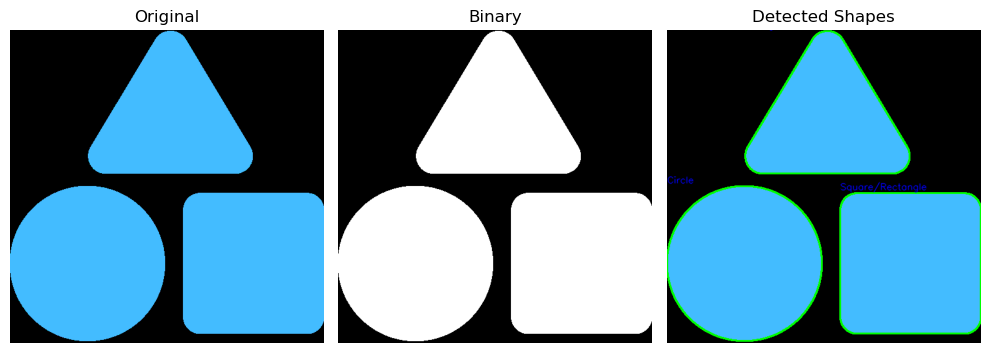

In [6]:
# 1. Load and prepare the image (same style as notes)
img = cv2.imread(im3)
if img is None:
    raise FileNotFoundError("Could not find 'shapes2.png' in the current folder.")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 2. Thresholding for segmentation (object vs background)
_, binary = cv2.threshold(gray, 120, 255, cv2.THRESH_BINARY)

# 3. Find contours (outer objects only)
contours, hierarchy = cv2.findContours(binary, cv2.RETR_EXTERNAL,
                                       cv2.CHAIN_APPROX_SIMPLE)

print("Total contours detected:", len(contours))

# 4. Analyze each contour: area, perimeter, shape classification
results = []
output_img = img.copy()

for i, cnt in enumerate(contours):
    # Area & perimeter (from notes)
    area = cv2.contourArea(cnt)
    perimeter = cv2.arcLength(cnt, True)

    # Approximate shape (using approxPolyDP like in slides)
    approx = cv2.approxPolyDP(cnt, 0.04 * perimeter, True)
    sides = len(approx)

    # Shape classification based on number of sides
    if sides == 3:
        shape_name = "Triangle"
    elif sides == 4:
        shape_name = "Square/Rectangle"
    else:
        shape_name = "Circle"
    
    # Save to list (for DataFrame)
    results.append({
        "object_id": i + 1,
        "shape": shape_name,
        "area": area,
        "perimeter": perimeter
    })

    # Draw contour and put label near it
    cv2.drawContours(output_img, [cnt], -1, (0, 255, 0), 2)

    # Get center for text placement using bounding rect
    x, y, w, h = cv2.boundingRect(cnt)
    cv2.putText(output_img, f"{shape_name}",
                (x, y - 5), cv2.FONT_HERSHEY_SIMPLEX,
                0.5, (255, 0, 0), 1, cv2.LINE_AA)

# 5. Create DataFrame summary table
df = pd.DataFrame(results)
print("\n--- Shape Summary table")
print(df)

# 6. Visualize images
plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.title("Original")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Binary")
plt.imshow(binary, cmap="gray")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Detected Shapes")
plt.imshow(cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.tight_layout()
plt.show()

# Q3 – Defective Parts Detection

Total contours detected: 3469
Area threshold (0.5 * median area): 0.00
Part 1: Area=0.00, Convexity Defects=0, Defective=False
Part 2: Area=0.00, Convexity Defects=0, Defective=False
Part 3: Area=0.00, Convexity Defects=0, Defective=False
Part 4: Area=0.00, Convexity Defects=0, Defective=False
Part 5: Area=0.00, Convexity Defects=0, Defective=False
Part 6: Area=0.00, Convexity Defects=0, Defective=False
Part 7: Area=0.50, Convexity Defects=0, Defective=False
Part 8: Area=0.50, Convexity Defects=0, Defective=False
Part 9: Area=1.00, Convexity Defects=0, Defective=False
Part 10: Area=0.50, Convexity Defects=0, Defective=False
Part 11: Area=0.00, Convexity Defects=0, Defective=False
Part 12: Area=0.00, Convexity Defects=0, Defective=False
Part 13: Area=0.00, Convexity Defects=0, Defective=False
Part 14: Area=7.00, Convexity Defects=3, Defective=False
Part 15: Area=8.00, Convexity Defects=3, Defective=False
Part 16: Area=9.50, Convexity Defects=4, Defective=False
Part 17: Area=2.00, Convex

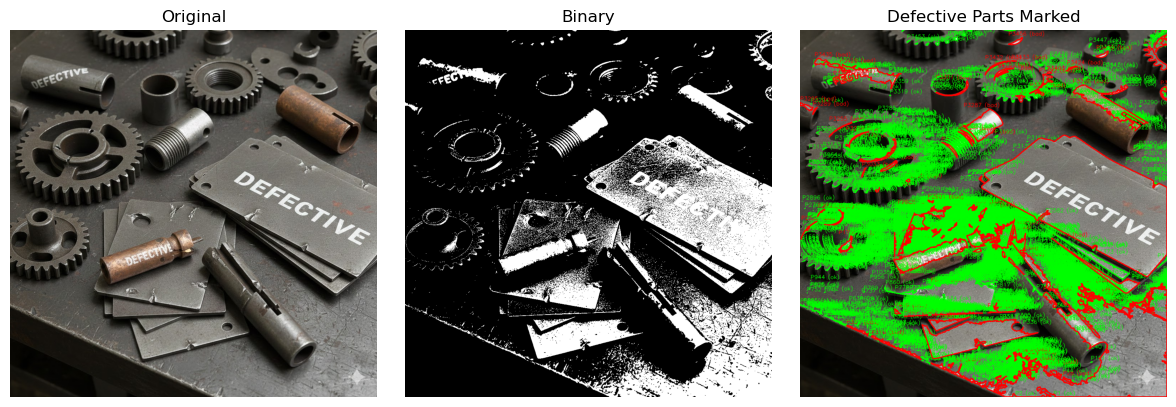

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Load image
img = cv2.imread(im5)
if img is None:
    raise FileNotFoundError("Could not find 'metal_parts.png' in the current folder.")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 2. Threshold to get binary image (similar to other contour problems in notes)
_, binary = cv2.threshold(gray, 120, 255, cv2.THRESH_BINARY)

# Optional: invert if needed (depends on image, uncomment if parts appear black)
# binary = cv2.bitwise_not(binary)

# 3. Find contours (each part is one contour)
contours, hierarchy = cv2.findContours(binary, cv2.RETR_EXTERNAL,
                                       cv2.CHAIN_APPROX_SIMPLE)

print("Total contours detected:", len(contours))

# 4. Compute area list first (for area threshold decision)
areas = [cv2.contourArea(cnt) for cnt in contours]
areas = np.array(areas)

# Set area threshold: here we use 0.5 * median area (you can tune as needed)
area_threshold = 0.5 * np.median(areas)
print(f"Area threshold (0.5 * median area): {area_threshold:.2f}")

# 5. Analyze each part: convexity defects + area
output_img = img.copy()
defective_count = 0

for i, cnt in enumerate(contours):
    area = cv2.contourArea(cnt)

    # Compute convex hull (indices form)
    hull = cv2.convexHull(cnt, returnPoints=False)

    # Default: assume no defects
    defects = None
    defect_num = 0

    # Only try convexityDefects if:
    # - hull exists
    # - enough points
    # - contour is NOT already convex
    if hull is not None and len(hull) > 3 and not cv2.isContourConvex(cnt):
        try:
            defects = cv2.convexityDefects(cnt, hull)
            if defects is not None:
                defect_num = defects.shape[0]
        except cv2.error:
            # Some strange contour → just ignore defects for this one
            defects = None
            defect_num = 0

    # Defect condition from question
    is_defective = (defect_num > 5) or (area < area_threshold)

    if is_defective:
        defective_count += 1
        color = (0, 0, 255)   # Red for defective
    else:
        color = (0, 255, 0)   # Green for good

    # Draw contour
    cv2.drawContours(output_img, [cnt], -1, color, 2)

    # Label each part with ID and status
    x, y, w, h = cv2.boundingRect(cnt)
    label = f"P{i+1}"
    if is_defective:
        label += " (bad)"
    else:
        label += " (ok)"

    cv2.putText(output_img, label, (x, y - 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1, cv2.LINE_AA)

    print(f"Part {i+1}: Area={area:.2f}, Convexity Defects={defect_num}, Defective={is_defective}")


# 6. Summary stats
total_parts = len(contours)
defective_parts = defective_count
defect_percentage = (defective_parts / total_parts * 100) if total_parts > 0 else 0

print("\n--- Summary ---")
print(f"Total parts         : {total_parts}")
print(f"Defective parts     : {defective_parts}")
print(f"Defect percentage   : {defect_percentage:.2f}%")

# 7. Show original, binary, and result
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.title("Original")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Binary")
plt.imshow(binary, cmap="gray")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Defective Parts Marked")
plt.imshow(cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.tight_layout()
plt.show()


# Q4 - Compute each coin’s radius using enclosing circles 

Detected regions (before filtering): 7
Filtered coins (final): 6
Final number of coins detected: 6
Using clusters: 4


C:\Users\neelj\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Total coin value: ₹ 18


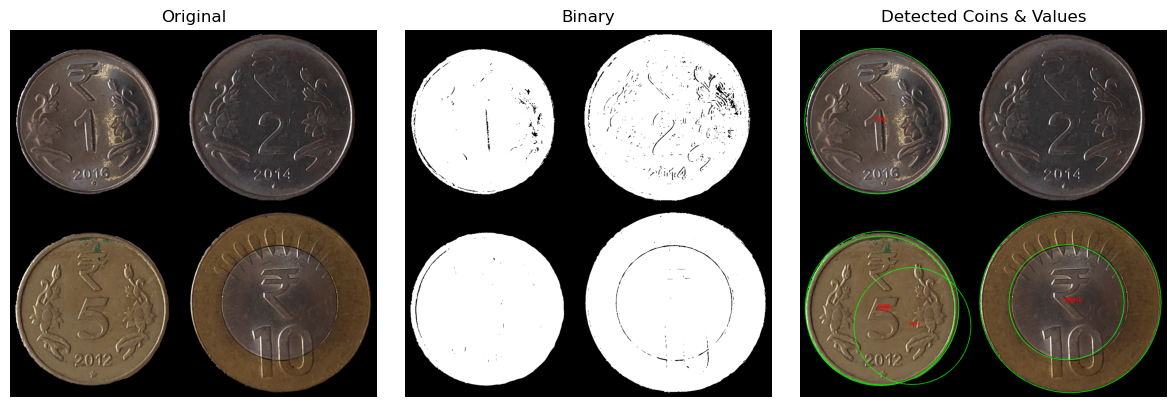

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import os

# Silence MKL warning (optional)
os.environ["OMP_NUM_THREADS"] = "1"

# -------------------------------------------------
# 1. Load image
# -------------------------------------------------
img = cv2.imread(im2)
if img is None:
    raise FileNotFoundError("coins.jpg not found. Check file path.")

orig = img.copy()
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# -------------------------------------------------
# 2. Thresholding (coins = white)
# -------------------------------------------------
_, binary = cv2.threshold(
    gray, 0, 255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

# -------------------------------------------------
# 3. Morphological opening (noise removal)
# -------------------------------------------------
kernel = np.ones((3, 3), np.uint8)
opening = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=2)

# -------------------------------------------------
# 4. Distance Transform + Watershed (separate coins)
# -------------------------------------------------
dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)

_, sure_fg = cv2.threshold(
    dist_transform,
    0.5 * dist_transform.max(),
    255,
    0
)

sure_fg = np.uint8(sure_fg)
sure_bg = cv2.dilate(opening, kernel, iterations=3)
unknown = cv2.subtract(sure_bg, sure_fg)

_, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1
markers[unknown == 255] = 0

markers = cv2.watershed(img, markers)

# -------------------------------------------------
# 5. Extract contours from watershed markers
# -------------------------------------------------
regions = []
for marker_id in np.unique(markers):
    if marker_id <= 1:
        continue
    mask = np.uint8(markers == marker_id) * 255
    cnts, _ = cv2.findContours(
        mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )
    regions.extend(cnts)

print("Detected regions (before filtering):", len(regions))

# -------------------------------------------------
# 6. Median-area filtering (remove fragments)
# -------------------------------------------------
areas = np.array([cv2.contourArea(cnt) for cnt in regions])
median_area = np.median(areas)

filtered_coins = []
for cnt, area in zip(regions, areas):
    if area >= 0.5 * median_area:
        filtered_coins.append(cnt)

coins = filtered_coins
print("Filtered coins (final):", len(coins))

# -------------------------------------------------
# 7. Compute coin radii
# -------------------------------------------------
radii = []
for cnt in coins:
    (_, _), r = cv2.minEnclosingCircle(cnt)
    radii.append(r)

radii = np.array(radii)
num_coins = len(radii)
print("Final number of coins detected:", num_coins)

if num_coins == 0:
    raise ValueError("No coins detected")

# -------------------------------------------------
# 8. SAFE KMeans clustering (dynamic)
# -------------------------------------------------
denominations = [1, 2, 5, 10]

num_clusters = min(num_coins, len(denominations))
print("Using clusters:", num_clusters)

radii_reshaped = radii.reshape(-1, 1)

kmeans = KMeans(n_clusters=num_clusters, random_state=0)
labels = kmeans.fit_predict(radii_reshaped)
centers = kmeans.cluster_centers_.flatten()

# Sort clusters by radius (small → large)
sorted_indices = np.argsort(centers)

coin_map = {}
for i, cluster_idx in enumerate(sorted_indices):
    coin_map[cluster_idx] = denominations[i]

# -------------------------------------------------
# 9. Annotate coins & compute total value
# -------------------------------------------------
annotated = orig.copy()
total_value = 0
counted_clusters = set()

for i, cnt in enumerate(coins):
    label = labels[i]
    value = coin_map[label]

    # Count each denomination once
    if label not in counted_clusters:
        total_value += value
        counted_clusters.add(label)

    (x, y), radius = cv2.minEnclosingCircle(cnt)
    center = (int(x), int(y))

    cv2.circle(annotated, center, int(radius), (0, 255, 0), 2)
    cv2.putText(
        annotated,
        f"₹{value}",
        (center[0] - 15, center[1]),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (0, 0, 255),
        2
    )

print("Total coin value: ₹", total_value)

# -------------------------------------------------
# 10. Display results
# -------------------------------------------------
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.title("Original")
plt.imshow(cv2.cvtColor(orig, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Binary")
plt.imshow(binary, cmap="gray")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Detected Coins & Values")
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.tight_layout()
plt.show()


# Q5 - Extract bounding box coordinates, and then generate a scatter-like plot of object centroids (x,y).

BEFORE - Total detected contours: 5845
AFTER - Filtered object count: 8


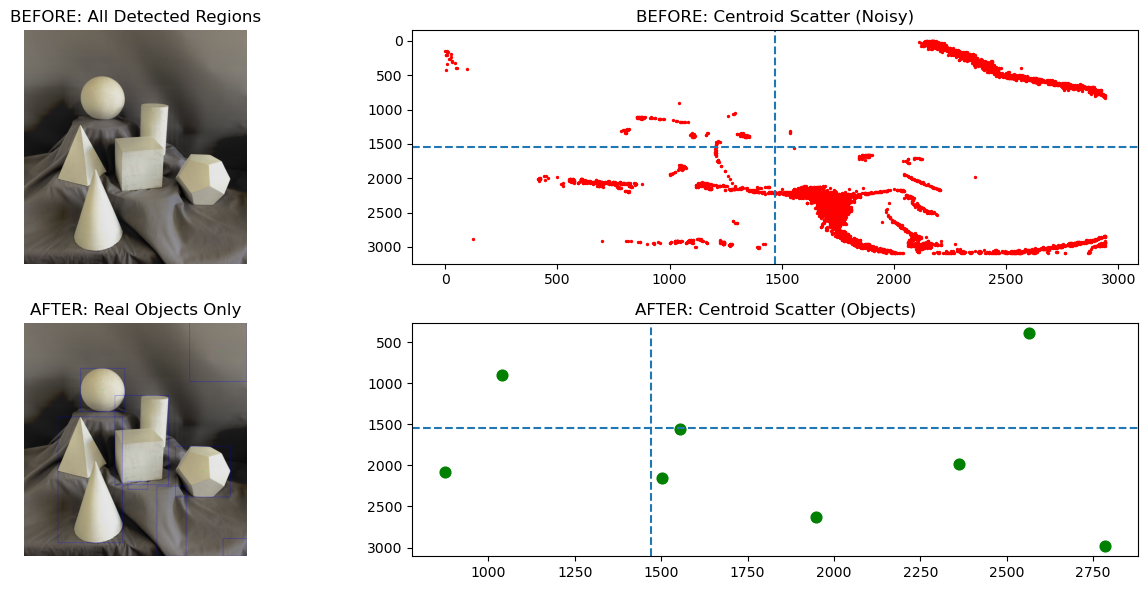

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# 1. Load image
# -------------------------------------------------
img = cv2.imread(im4)
if img is None:
    raise FileNotFoundError("items.png not found")

orig = img.copy()
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# -------------------------------------------------
# 2. Thresholding
# -------------------------------------------------
_, binary = cv2.threshold(gray, 120, 255, cv2.THRESH_BINARY)

# -------------------------------------------------
# 3. Find ALL contours (BEFORE)
# -------------------------------------------------
contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL,
                               cv2.CHAIN_APPROX_SIMPLE)

h, w = gray.shape

# =========================
# BEFORE ANALYSIS
# =========================
bx, by = [], []
before_img = orig.copy()

for cnt in contours:
    x, y, bw, bh = cv2.boundingRect(cnt)
    cx = x + bw // 2
    cy = y + bh // 2
    bx.append(cx)
    by.append(cy)

print("BEFORE - Total detected contours:", len(contours))

# -------------------------------------------------
# 4. AREA FILTERING (KEY FIX)
# -------------------------------------------------
MIN_AREA = 3000   # adjust if needed

filtered_contours = []
for cnt in contours:
    if cv2.contourArea(cnt) > MIN_AREA:
        filtered_contours.append(cnt)

print("AFTER - Filtered object count:", len(filtered_contours))

# =========================
# AFTER ANALYSIS
# =========================
ax, ay = [], []
after_img = orig.copy()

for cnt in filtered_contours:
    x, y, bw, bh = cv2.boundingRect(cnt)
    cx = x + bw // 2
    cy = y + bh // 2

    ax.append(cx)
    ay.append(cy)

    cv2.rectangle(after_img, (x, y), (x + bw, y + bh), (255, 0, 0), 2)
    cv2.circle(after_img, (cx, cy), 5, (0, 255, 0), -1)

# -------------------------------------------------
# 5. PLOTS
# -------------------------------------------------
plt.figure(figsize=(14, 6))

# BEFORE IMAGE
plt.subplot(2, 2, 1)
plt.title("BEFORE: All Detected Regions")
plt.imshow(cv2.cvtColor(orig, cv2.COLOR_BGR2RGB))
plt.axis("off")

# BEFORE SCATTER
plt.subplot(2, 2, 2)
plt.scatter(bx, by, s=2, c="red")
plt.axvline(w//2, linestyle="--")
plt.axhline(h//2, linestyle="--")
plt.gca().invert_yaxis()
plt.title("BEFORE: Centroid Scatter (Noisy)")

# AFTER IMAGE
plt.subplot(2, 2, 3)
plt.title("AFTER: Real Objects Only")
plt.imshow(cv2.cvtColor(after_img, cv2.COLOR_BGR2RGB))
plt.axis("off")

# AFTER SCATTER
plt.subplot(2, 2, 4)
plt.scatter(ax, ay, s=60, c="green")
plt.axvline(w//2, linestyle="--")
plt.axhline(h//2, linestyle="--")
plt.gca().invert_yaxis()
plt.title("AFTER: Centroid Scatter (Objects)")

plt.tight_layout()
plt.show()


# Q6 - Extract contour areas from "geometric_objects.jpg".Plot a histogram of all contour areas using Matplotlib

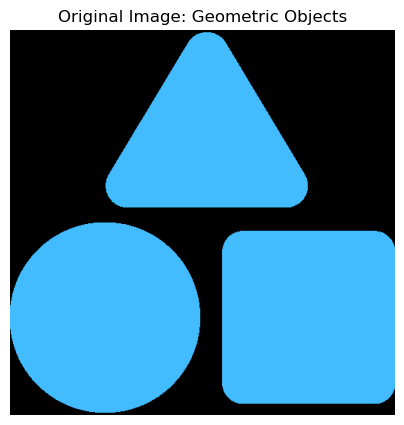

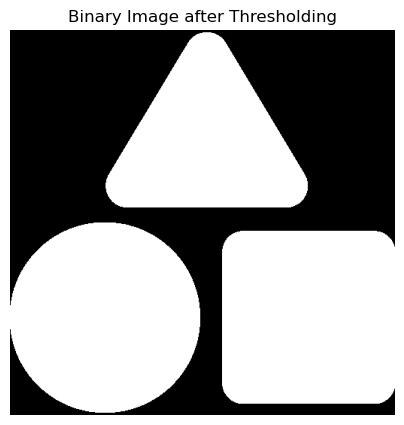

Total contours detected: 3


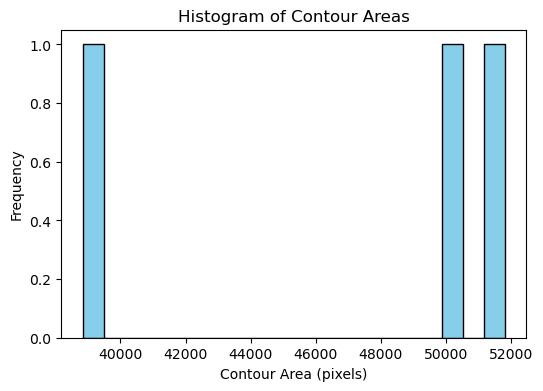

Minimum area: 38835.5
Maximum area: 51827.5
Mean area: 46962.333333333336
Median area: 50224.0


In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# 1. Load image
# -------------------------------------------------
img = cv2.imread(im3)
if img is None:
    raise FileNotFoundError("geometric_objects.jpg not found")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# -------------------------------------------------
# SHOW ORIGINAL IMAGE
# -------------------------------------------------
plt.figure(figsize=(5, 5))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original Image: Geometric Objects")
plt.axis("off")
plt.show()

# -------------------------------------------------
# 2. Thresholding
# -------------------------------------------------
_, binary = cv2.threshold(gray, 120, 255, cv2.THRESH_BINARY)

# -------------------------------------------------
# SHOW BINARY IMAGE
# -------------------------------------------------
plt.figure(figsize=(5, 5))
plt.imshow(binary, cmap="gray")
plt.title("Binary Image after Thresholding")
plt.axis("off")
plt.show()

# -------------------------------------------------
# 3. Find contours
# -------------------------------------------------
contours, _ = cv2.findContours(
    binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
)

print("Total contours detected:", len(contours))

# -------------------------------------------------
# 4. Compute contour areas
# -------------------------------------------------
areas = []
for cnt in contours:
    area = cv2.contourArea(cnt)
    areas.append(area)

areas = np.array(areas)

# -------------------------------------------------
# 5. Plot histogram of contour areas
# -------------------------------------------------
plt.figure(figsize=(6, 4))
plt.hist(areas, bins=20, color='skyblue', edgecolor='black')
plt.xlabel("Contour Area (pixels)")
plt.ylabel("Frequency")
plt.title("Histogram of Contour Areas")
plt.show()

# -------------------------------------------------
# 6. Print statistics
# -------------------------------------------------
print("Minimum area:", np.min(areas))
print("Maximum area:", np.max(areas))
print("Mean area:", np.mean(areas))
print("Median area:", np.median(areas))


* No. The objects have different sizes, as indicated by distinct peaks at different contour areas in the histogram.
* No significant outliers are present. All contour areas correspond to valid geometric objects, and no extremely small or large areas are observed.

# Q7 Using "crops.jpg", apply:
* global thresholding
* adaptive thresholding
* For each method, count detected objects and calculate:
* nmean object area
*number of missed objects


Comparison Table:

                  Method  Detected Objects  Mean Object Area  \
0    Global Thresholding                 8          24109.19   
1  Adaptive Thresholding                 2         160526.25   

   Missed Objects (Small Regions)  
0                             721  
1                             263  


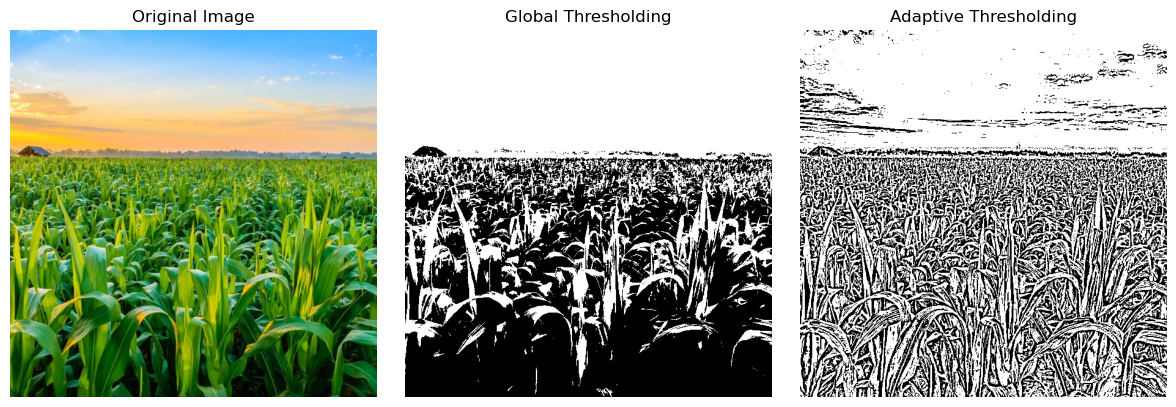

In [11]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------
# 1. Load image
# -------------------------------------------------
img = cv2.imread(im8)
if img is None:
    raise FileNotFoundError("crops.jpg not found")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# -------------------------------------------------
# 2. Global Thresholding
# -------------------------------------------------
_, global_thresh = cv2.threshold(
    gray, 127, 255, cv2.THRESH_BINARY
)

# -------------------------------------------------
# 3. Adaptive Thresholding
# -------------------------------------------------
adaptive_thresh = cv2.adaptiveThreshold(
    gray,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    11,
    2
)

# -------------------------------------------------
# 4. Analysis function
# -------------------------------------------------
def analyze(binary_img, min_area=500):
    contours, _ = cv2.findContours(
        binary_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    valid_areas = []
    missed = 0

    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area >= min_area:
            valid_areas.append(area)
        else:
            missed += 1  # small regions = missed objects

    if len(valid_areas) == 0:
        return 0, 0, missed

    mean_area = np.mean(valid_areas)
    return len(valid_areas), mean_area, missed


# -------------------------------------------------
# 5. Analyze both methods
# -------------------------------------------------
g_count, g_mean_area, g_missed = analyze(global_thresh)
a_count, a_mean_area, a_missed = analyze(adaptive_thresh)

# -------------------------------------------------
# 6. Comparison Table
# -------------------------------------------------
table = pd.DataFrame({
    "Method": ["Global Thresholding", "Adaptive Thresholding"],
    "Detected Objects": [g_count, a_count],
    "Mean Object Area": [round(g_mean_area, 2), round(a_mean_area, 2)],
    "Missed Objects (Small Regions)": [g_missed, a_missed]
})

print("\nComparison Table:\n")
print(table)

# -------------------------------------------------
# 7. Display results
# -------------------------------------------------
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.title("Original Image")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Global Thresholding")
plt.imshow(global_thresh, cmap="gray")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Adaptive Thresholding")
plt.imshow(adaptive_thresh, cmap="gray")
plt.axis("off")

plt.tight_layout()
plt.show()


# Q8 - Add Gaussian noise to "packets.jpg", then detect contours before and after applying median filtering. 

Contours BEFORE filtering: 262
Contours AFTER filtering : 5
Difference in contours   : 257
Average area BEFORE      : 110.18
Average area AFTER       : 6040.0
Change in average area   : 5929.82
Detection accuracy improvement (%): 98.09


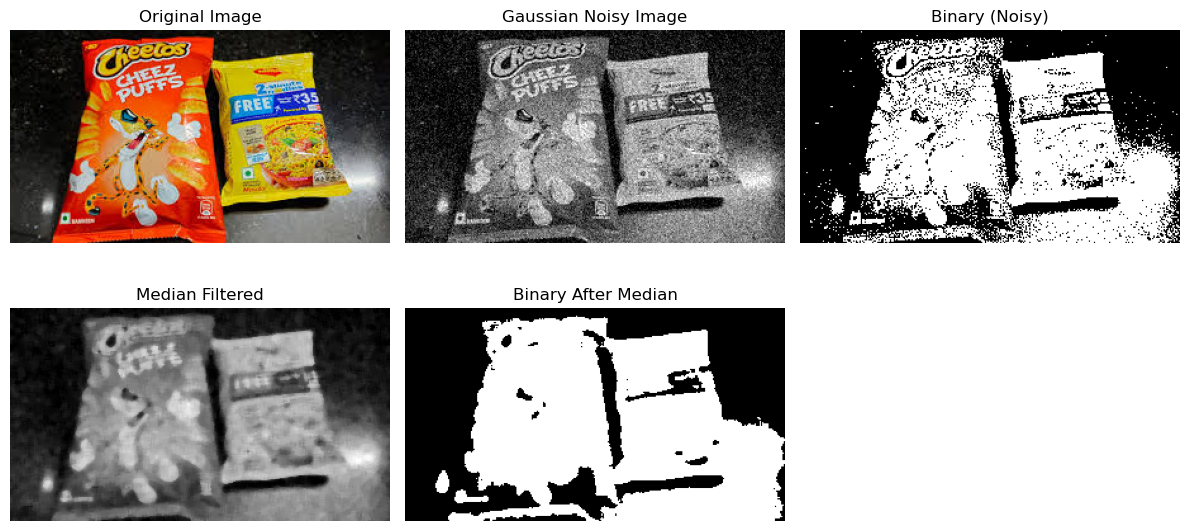

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# 1. Load image
# -------------------------------------------------
img = cv2.imread(im9)
if img is None:
    raise FileNotFoundError("packets.jpg not found")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# -------------------------------------------------
# 2. Add Gaussian noise
# -------------------------------------------------
mean = 0
sigma = 25
gaussian_noise = np.random.normal(mean, sigma, gray.shape).astype(np.int16)

noisy_img = gray.astype(np.int16) + gaussian_noise
noisy_img = np.clip(noisy_img, 0, 255).astype(np.uint8)

# -------------------------------------------------
# 3. Threshold noisy image
# -------------------------------------------------
_, noisy_binary = cv2.threshold(
    noisy_img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

# -------------------------------------------------
# 4. Contours BEFORE filtering
# -------------------------------------------------
contours_before, _ = cv2.findContours(
    noisy_binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
)

areas_before = [cv2.contourArea(cnt) for cnt in contours_before]
avg_area_before = np.mean(areas_before)

# -------------------------------------------------
# 5. Median filtering
# -------------------------------------------------
median_filtered = cv2.medianBlur(noisy_img, 5)

_, median_binary = cv2.threshold(
    median_filtered, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

# -------------------------------------------------
# 6. Contours AFTER filtering
# -------------------------------------------------
contours_after, _ = cv2.findContours(
    median_binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
)

areas_after = [cv2.contourArea(cnt) for cnt in contours_after]
avg_area_after = np.mean(areas_after)

# -------------------------------------------------
# 7. Metrics calculation
# -------------------------------------------------
num_before = len(contours_before)
num_after = len(contours_after)

difference_contours = num_before - num_after
change_avg_area = avg_area_after - avg_area_before

accuracy_improvement = (difference_contours / num_before) * 100

# -------------------------------------------------
# 8. Print results
# -------------------------------------------------
print("Contours BEFORE filtering:", num_before)
print("Contours AFTER filtering :", num_after)
print("Difference in contours   :", difference_contours)
print("Average area BEFORE      :", round(avg_area_before, 2))
print("Average area AFTER       :", round(avg_area_after, 2))
print("Change in average area   :", round(change_avg_area, 2))
print("Detection accuracy improvement (%):",
      round(accuracy_improvement, 2))

# -------------------------------------------------
# 9. Visualization
# -------------------------------------------------
plt.figure(figsize=(12, 6))

plt.subplot(2, 3, 1)
plt.title("Original Image")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(2, 3, 2)
plt.title("Gaussian Noisy Image")
plt.imshow(noisy_img, cmap="gray")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.title("Binary (Noisy)")
plt.imshow(noisy_binary, cmap="gray")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.title("Median Filtered")
plt.imshow(median_filtered, cmap="gray")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.title("Binary After Median")
plt.imshow(median_binary, cmap="gray")
plt.axis("off")

plt.tight_layout()
plt.show()


# Q9 - Detect all rectangular objects in "boxes.png".For each bounding rectangle, compute the angle of orientation using minAreaRect().


Detected Box Orientation Table:

   Box ID  Orientation Angle (deg)  Area (pixels)
0       1                    86.52         8041.5
1       2                    82.18        10514.0
2       3                    90.00        13595.5
3       4                    90.00         8395.0
4       5                     5.26         9021.5
5       6                     7.35        11051.5
6       7                    90.00         9009.5
7       8                    50.36         8557.5
8       9                    90.00        11419.0


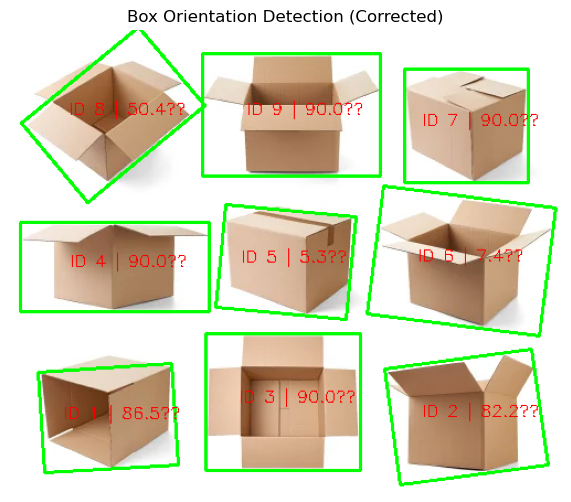

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# -------------------------------------------------
# 1. Load image
# -------------------------------------------------
img = cv2.imread(im10)
if img is None:
    raise FileNotFoundError("boxes.png not found")

orig = img.copy()
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# -------------------------------------------------
# 2. Preprocessing
# -------------------------------------------------
blur = cv2.GaussianBlur(gray, (7, 7), 0)

edges = cv2.Canny(blur, 50, 150)

kernel = np.ones((5, 5), np.uint8)
edges = cv2.dilate(edges, kernel, iterations=1)

# -------------------------------------------------
# 3. Find contours
# -------------------------------------------------
contours, _ = cv2.findContours(
    edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
)

box_data = []
box_id = 1

# -------------------------------------------------
# 4. Process contours (NO polygon constraint)
# -------------------------------------------------
for cnt in contours:
    area = cv2.contourArea(cnt)

    # Filter very small regions
    if area < 8000:
        continue

    rect = cv2.minAreaRect(cnt)
    (cx, cy), (w, h), angle = rect

    # ✅ Proper angle normalization
    if angle < -45:
        angle += 90

    box = cv2.boxPoints(rect)
    box = box.astype(int)

    # Draw bounding rectangle
    cv2.drawContours(orig, [box], 0, (0, 255, 0), 2)

    # Label
    cv2.putText(
        orig,
        f"ID {box_id} | {angle:.1f}°",
        (int(cx) - 40, int(cy)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (0, 0, 255),
        1
    )

    box_data.append([box_id, round(angle, 2), round(area, 2)])
    box_id += 1

# -------------------------------------------------
# 5. Create DataFrame
# -------------------------------------------------
df = pd.DataFrame(
    box_data,
    columns=["Box ID", "Orientation Angle (deg)", "Area (pixels)"]
)

print("\nDetected Box Orientation Table:\n")
print(df)

# -------------------------------------------------
# 6. Display results
# -------------------------------------------------
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(orig, cv2.COLOR_BGR2RGB))
plt.title("Box Orientation Detection (Corrected)")
plt.axis("off")
plt.show()


## Many detected boxes have orientation angles close to 90° (≈ 86°–90°).
- In OpenCV’s minAreaRect, angles near 90° or 0° indicate alignment with the image axes.
- This means the majority of boxes are properly placed and aligned.
## Some boxes show noticeable deviation from alignment:
- ID 8 ≈ 50°
- ID 2 ≈ 82°
- ID 6 ≈ 7°
- ID 5 ≈ 5°

# Q10 - Perform Otsu’s thresholding on "fruits_segment.png", detect contours, and compute SSIM and PSNR between:
* original grayscale image
* binary mask scaled to 0–255

Number of contours detected: 1
SSIM between grayscale & binary mask: 0.715
PSNR between grayscale & binary mask: 11.81 dB


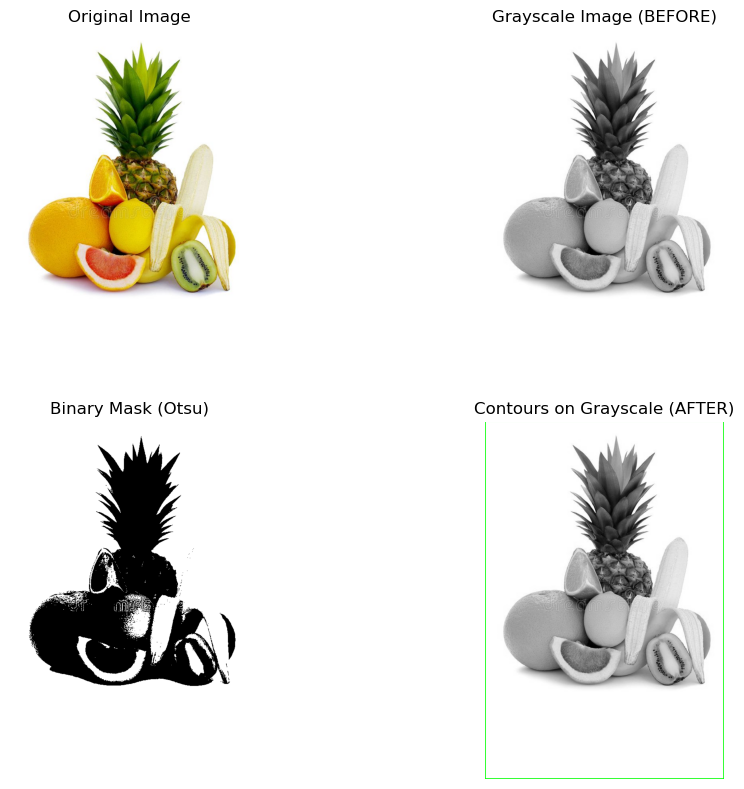

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr

# -------------------------------------------------
# 1. Load image
# -------------------------------------------------
img = cv2.imread(im11)
if img is None:
    raise FileNotFoundError("fruits_segment.png not found")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# -------------------------------------------------
# 2. Otsu's Thresholding
# -------------------------------------------------
_, binary_otsu = cv2.threshold(
    gray, 0, 255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

# -------------------------------------------------
# 3. Detect contours
# -------------------------------------------------
contours, _ = cv2.findContours(
    binary_otsu, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
)

print("Number of contours detected:", len(contours))

# -------------------------------------------------
# 4. Create contour overlay for visualization
# -------------------------------------------------
contour_img = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
cv2.drawContours(contour_img, contours, -1, (0, 255, 0), 2)

# -------------------------------------------------
# 5. Compute SSIM and PSNR
# -------------------------------------------------
ssim_value = ssim(gray, binary_otsu, data_range=255)
psnr_value = psnr(gray, binary_otsu, data_range=255)

print("SSIM between grayscale & binary mask:", round(ssim_value, 4))
print("PSNR between grayscale & binary mask:", round(psnr_value, 2), "dB")

# -------------------------------------------------
# 6. Visualization (BEFORE & AFTER)
# -------------------------------------------------
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.title("Original Image")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(2, 2, 2)
plt.title("Grayscale Image (BEFORE)")
plt.imshow(gray, cmap="gray")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.title("Binary Mask (Otsu)")
plt.imshow(binary_otsu, cmap="gray")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.title("Contours on Grayscale (AFTER)")
plt.imshow(cv2.cvtColor(contour_img, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.tight_layout()
plt.show()


* Segmentation is reasonable. Otsu’s method successfully separates fruit regions from the background, though fine texture information is lost due to binarization.
* Yes. The detected contours align well with object boundaries, indicating effective segmentation.
* Lower SSIM and PSNR values are expected because a binary image lacks grayscale detail present in the original image.